In [17]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *

S = $Tr[\rho_A log \rho_A]$

$\rho_A = Tr_{A}[\rho_{full}]$

$\rho_{full} = \ket{\psi(t)}\bra{\psi(t)}$

In [18]:
def embed_scar_state_to_full(state, basisList, N):
    vec_constrained = state.full().flatten()
    vec_full = np.zeros(2**N, dtype=complex)

    for i, bitstr in enumerate(basisList):
        full_index = int(bitstr, 2)
        vec_full[full_index] = vec_constrained[i]

    return qt.Qobj(vec_full, dims=[[2]*N, [1]*N])

In [19]:
wd = 0.642570281124498
tlist = np.linspace(0, 1000, 2000)
N = 4

scarEntangle = []

for _ in range(10):
    H0, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N, ham_disorder=[0, 1.0, 0], random_seed=True)
    args = {"A": 0.1, "omega": wd}
    H = qt.QobjEvo([H0, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist)

    temp = []
    for state in psi_t.states:
        psi_full = embed_scar_state_to_full(state, basisList, N)
        rho_A = psi_full.ptrace(list(range(N//2)))
        temp.append(qt.entropy_vn(rho_A))
    scarEntangle.append(temp)

# rho_A = psi_full.ptrace(list(range(N//2)))
# print(rho_A.dims)
# print(rho_A.shape)

# psi_full = embed_scar_state_to_full(psi_t.states[0], basisList, N)
# print(psi_full.dims)
# print(psi_full.shape)

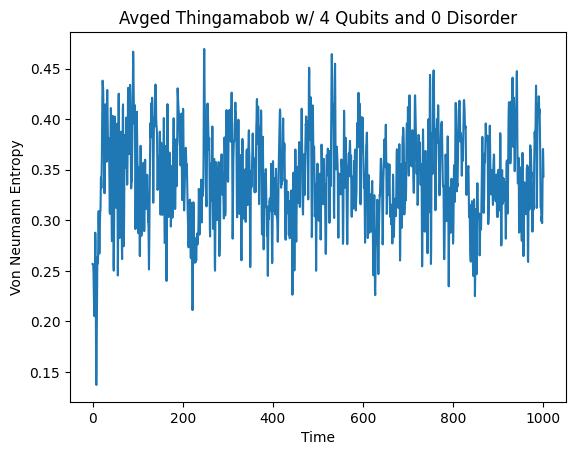

In [20]:
scarEntangle = np.array(scarEntangle)
plotScar = np.mean(scarEntangle, axis=0)

plt.plot(tlist, plotScar)
plt.title(f"Avged Thingamabob w/ {N} Qubits and {0} Disorder")
plt.ylabel("Von Neumann Entropy")
plt.xlabel("Time")
plt.show()